# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
error: uninstall-no-record-file

× Cannot uninstall numpy None
╰─> The package's contents are unknown: no RECORD file was found for numpy.

hint: You might be able to recover from this via: pip install --ignore-installed --no-deps numpy==1.26.4


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [4]:
kart = pd.read_csv("SuperKart.csv")
data = kart.copy()

# **Data Overview**

In [8]:
print(data.shape)
data.info()

(8763, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [5]:
data.head()
#Read in dataset and preview rows

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
data.tail() #view tail of dataset

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [9]:
#describe the dataset
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(data.duplicated().sum())

0


In [13]:
data.isnull().sum()
#we see that no rows are null

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

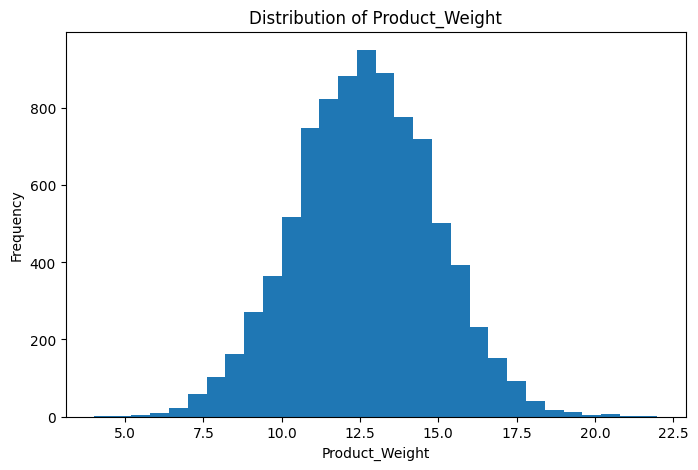

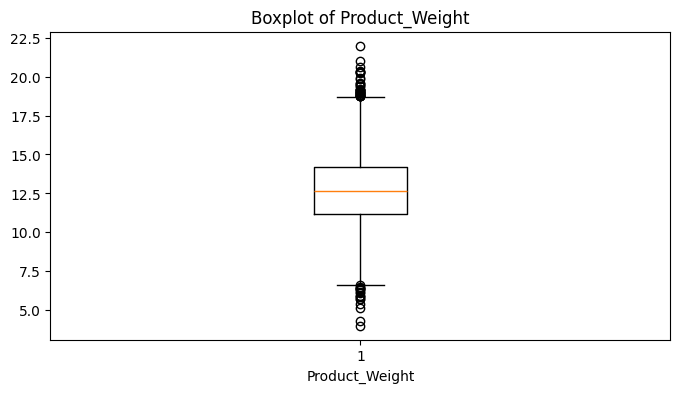

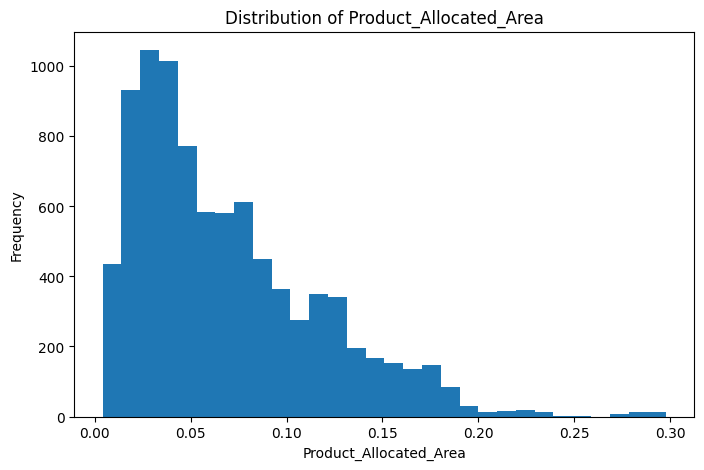

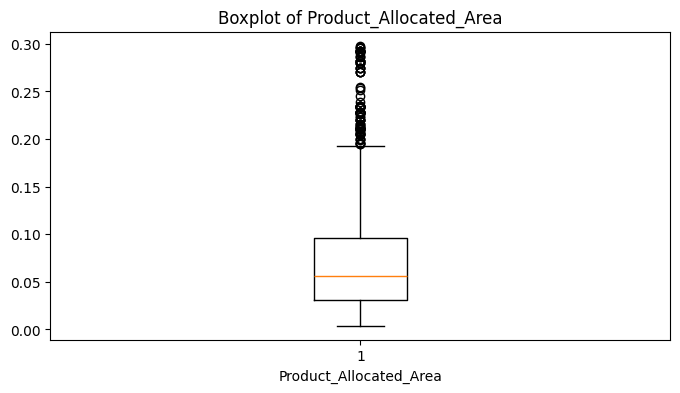

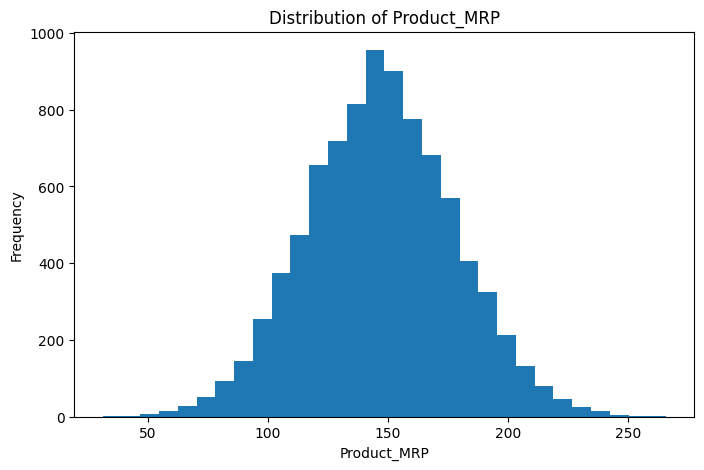

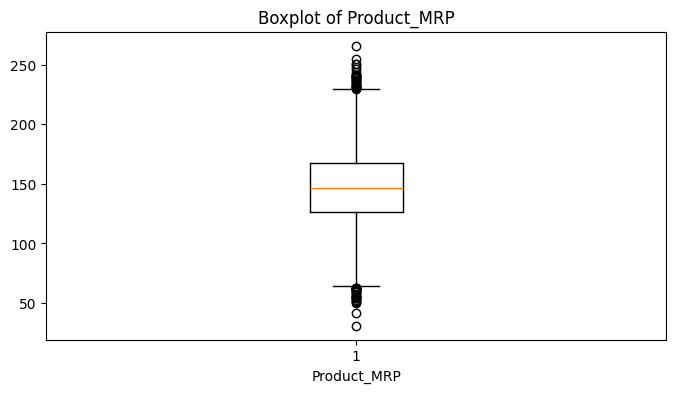

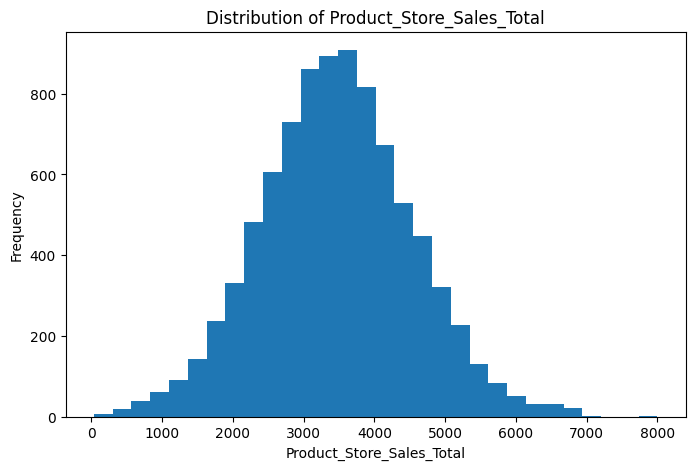

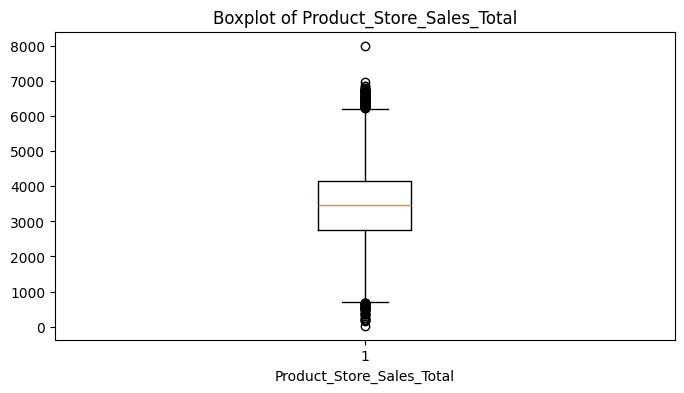

In [19]:
#To begin, I will plot histograms and box plots for numerical data columns
numeric_cols = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Product_Store_Sales_Total'
]


for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(data[col], bins=30)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()
    

    plt.figure(figsize=(8, 4))
    plt.boxplot(data[col])
    plt.xlabel(col)
    plt.title(f'Boxplot of {col}')
    plt.show()

Observations

For Product Weight, products appear to be normally distributed with a mean around 12.5, Several outliers do exist, which makes sense

Product Allocated Area is heavily skewed to the left, with the majority of allocated area being less then 0.10, there are several outliers above the 3q range of .2 

Product MRP is normally distributed with a mean of around 145

Product Store Sales Total is also normally distributed with an average around 3500,





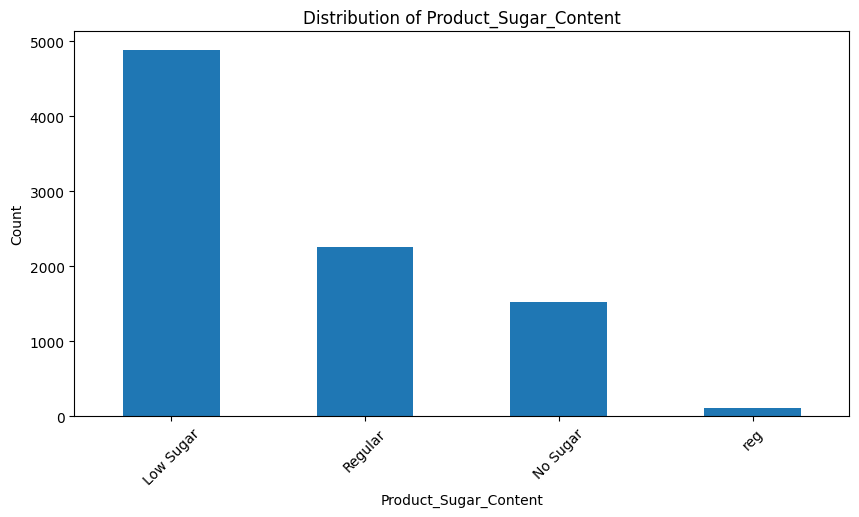

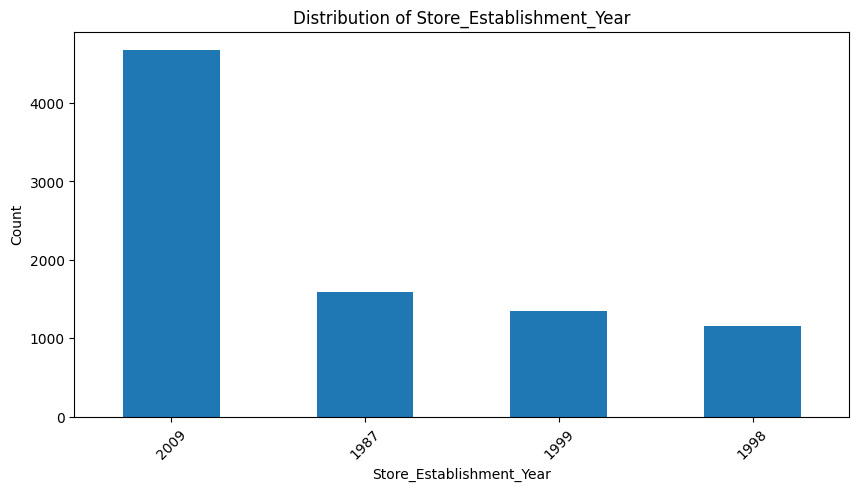

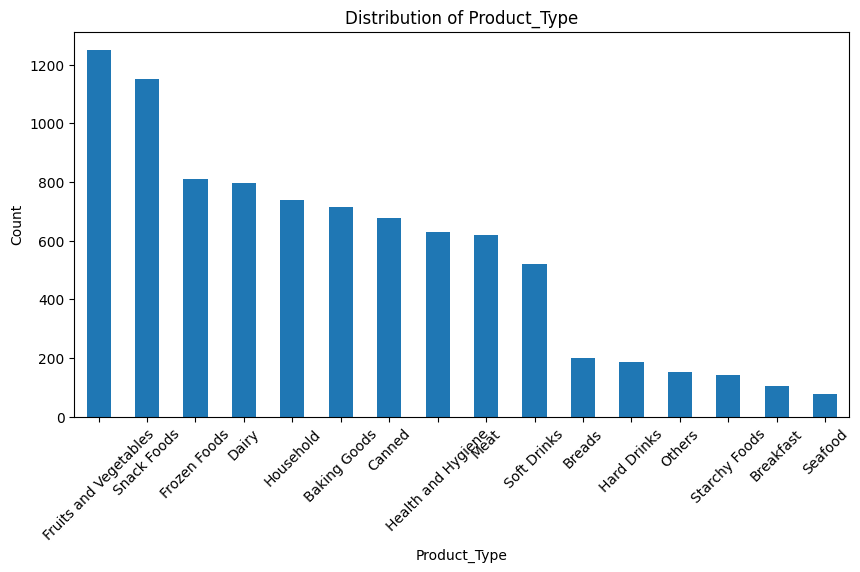

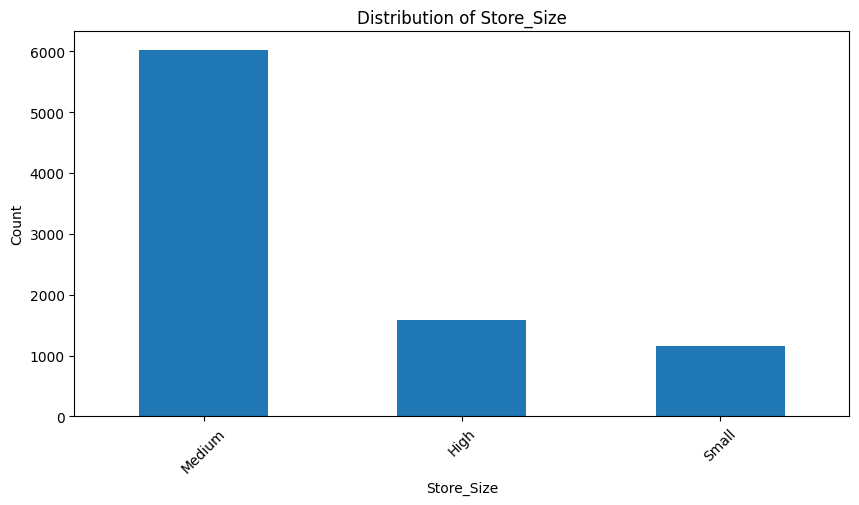

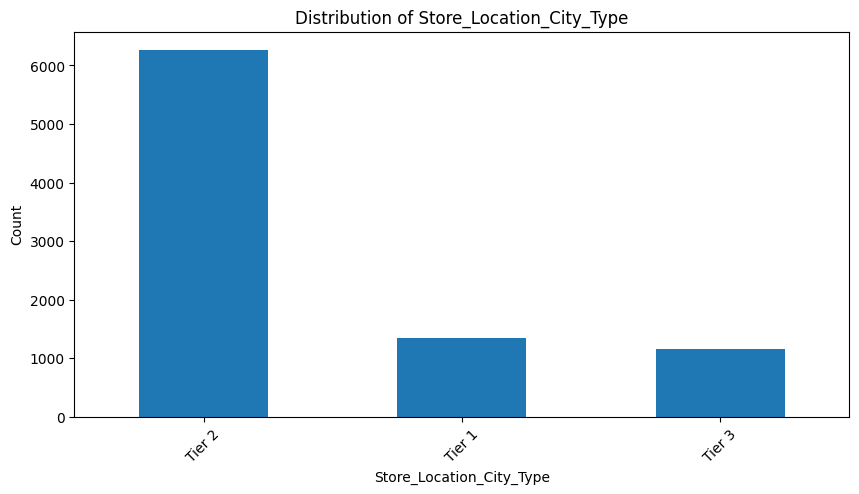

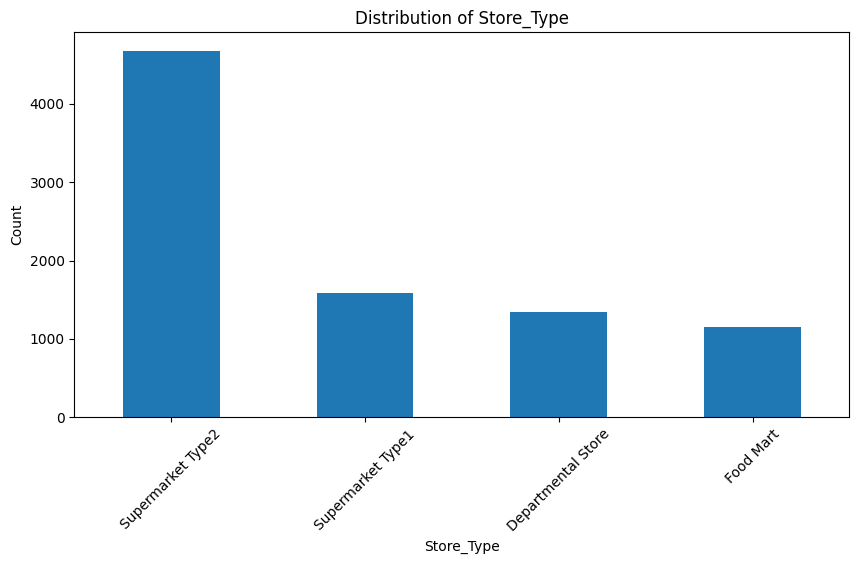

In [20]:
categorical_cols = [
    'Product_Sugar_Content',
    'Store_Establishment_Year',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    data[col].value_counts().plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [18]:
print(data['Product_Id'].nunique(), " number of unique products")
print(data['Store_Id'].nunique(), " number of unique stores")

8763  number of unique products
4  number of unique stores


Observations
Looking at the distribution of product sugar count, I see that there is overlap between 2 values, regular and reg, I will ad a block of code to fix that below

Store Establishment year shows that the most products are in the newest store establishment year, with the three older stores having a similar number of products.

Product Type shows us that the most populous foods are fruits and vegitagbles, snacks, frozen  foods, and dairy. 

Products are distributed more to medium stores, and less to high and small sized stores. Products are also more distributed in Tier 2 cities verse tier 1 and 3, as well as Supermarket Type2 compared to other store types



In [21]:
data['Product_Sugar_Content'] = data['Product_Sugar_Content'].replace('reg', 'Regular')
data['Product_Sugar_Content'].value_counts() #Confirming fix worked

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

## Bivariate Analysis

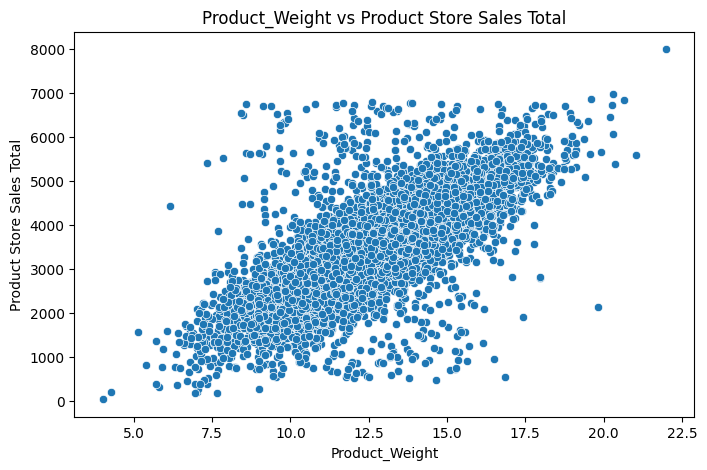

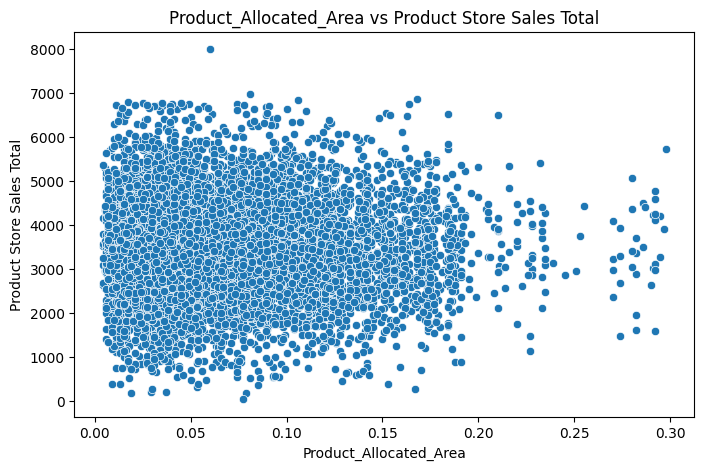

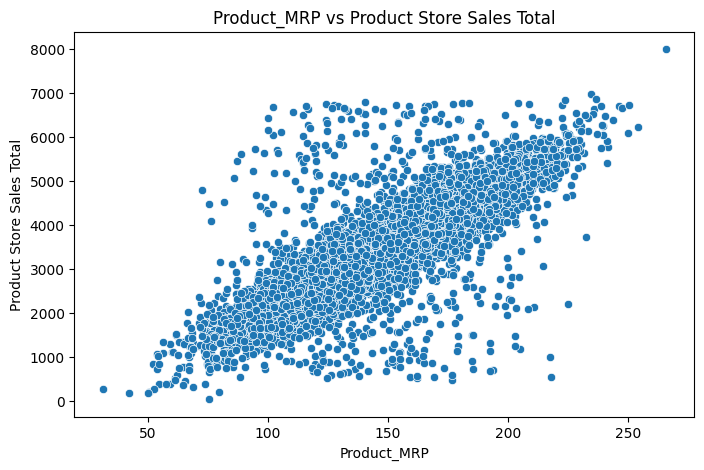

In [27]:
#In this section, I'm most interested in seeing how products sell, so comparing different categories of products/stores vs Sales


numeric_cols = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP'
]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=data, x=col, y='Product_Store_Sales_Total')
    plt.title(f'{col} vs Product Store Sales Total')
    plt.xlabel(col)
    plt.ylabel('Product Store Sales Total')
    plt.show()

Here, I am looking into the relationship between different numerical product categories vs Product Sales, In search of understanding the relationship. We see that there is a semi-strong positive correlation with Product MRP and Product Weight vs Store Sales, but not much correlation between product allocated area vs store sales. This makes sense as product allocated area doesn't inherently help with sales. 

In [28]:
data[numeric_cols + ['Product_Store_Sales_Total']].corr()['Product_Store_Sales_Total'].sort_values(ascending=False)

Product_Store_Sales_Total    1.000000
Product_MRP                  0.787989
Product_Weight               0.737955
Product_Allocated_Area      -0.000933
Name: Product_Store_Sales_Total, dtype: float64

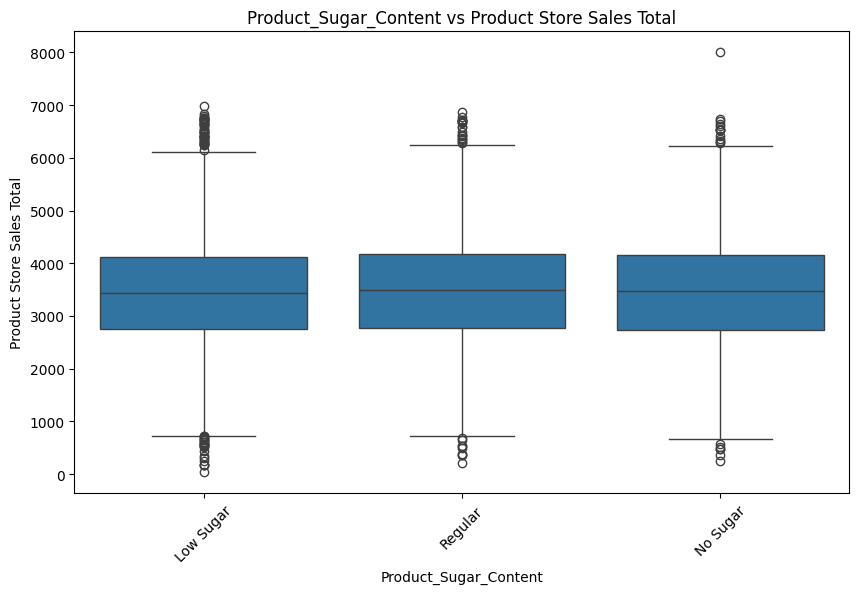

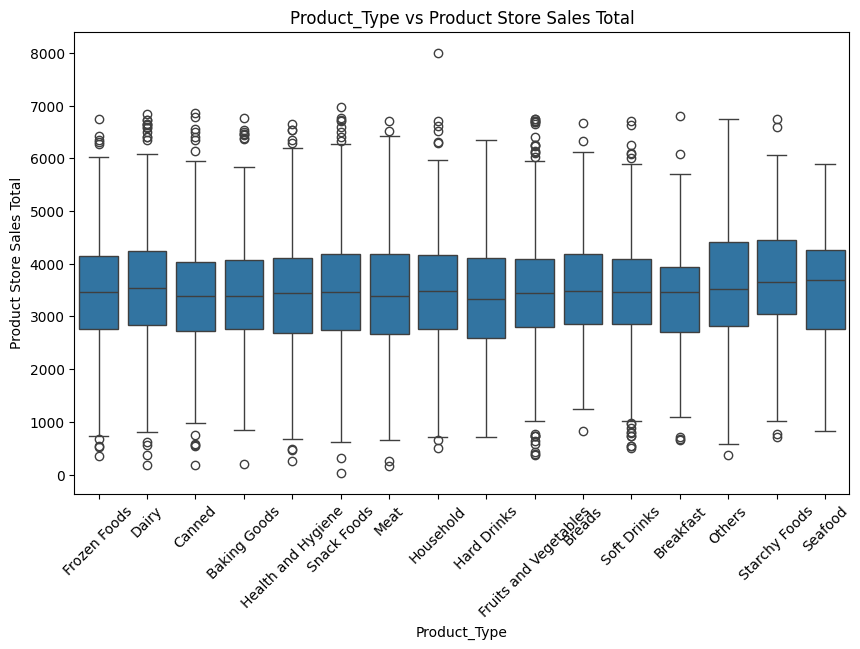

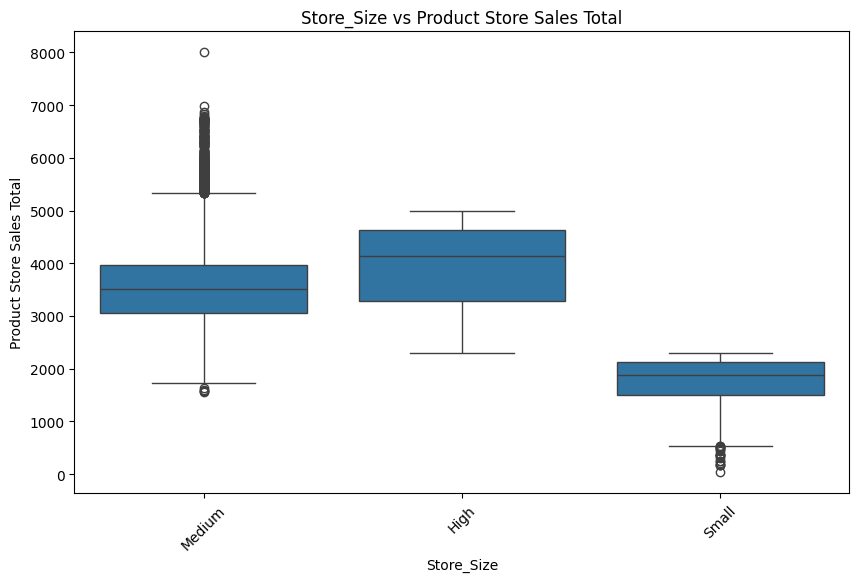

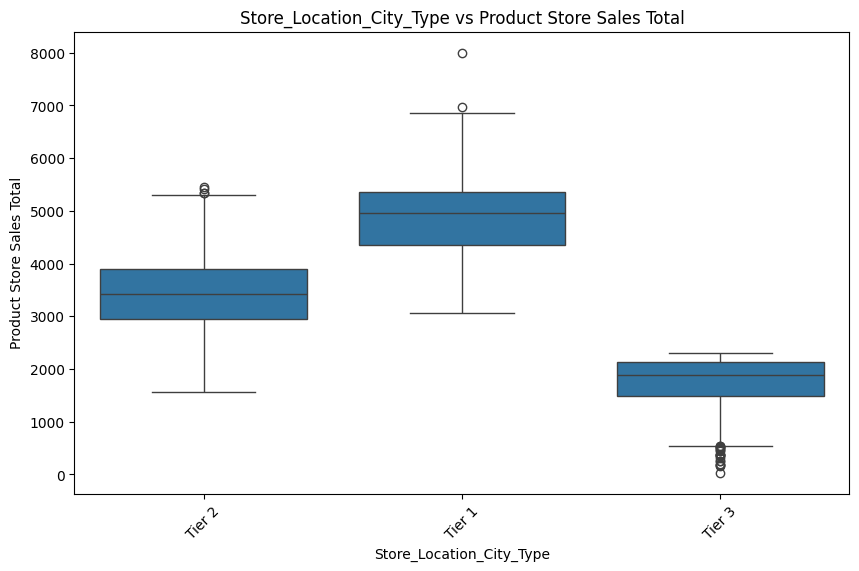

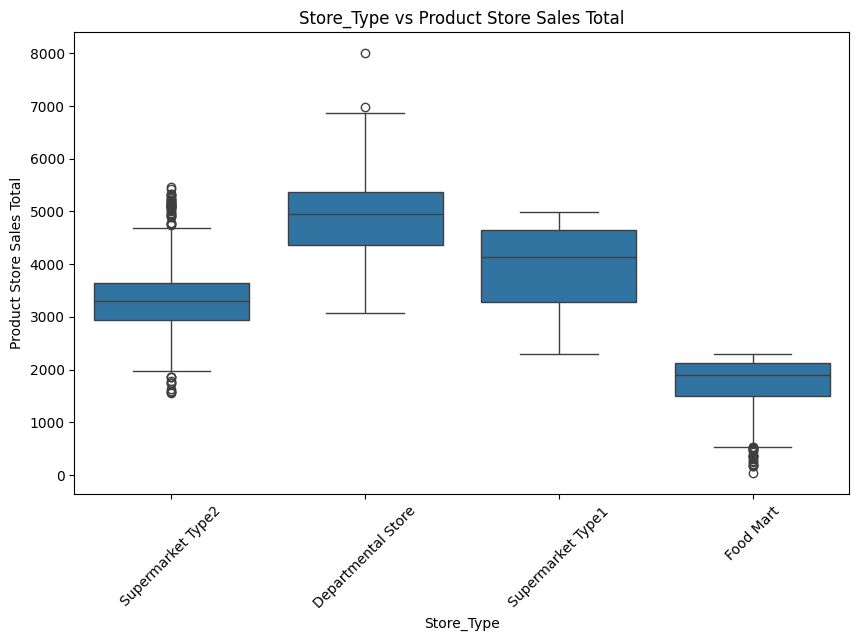

In [29]:
categorical_cols = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=col, y='Product_Store_Sales_Total')
    plt.title(f'{col} vs Product Store Sales Total')
    plt.xlabel(col)
    plt.ylabel('Product Store Sales Total')
    plt.xticks(rotation=45)
    plt.show()

Next I wanted to look at different values within the range of categorical variables vs. Product Store Sales Total

First, product sugar content shows not much of a difference in sales between low sugar, regular, and no sugar.

For Product Type, we also don't see any unusual outliers in terms of total store sales vs different types of products, although we do wee Dairy, and Starchy Foods being the highest in average sales. 

For Store Size for product Store sales total, we see a large increase in High compared to Medium compared to Small, which makes sense are larger store sizes can hold more products. We see similar trends for store location city type, store type, as the stores/locations are correlated with what products are inside the stores. 

I did some additional plots below to fully understand which product types are making the most money, since the box plots are hard to gauge.

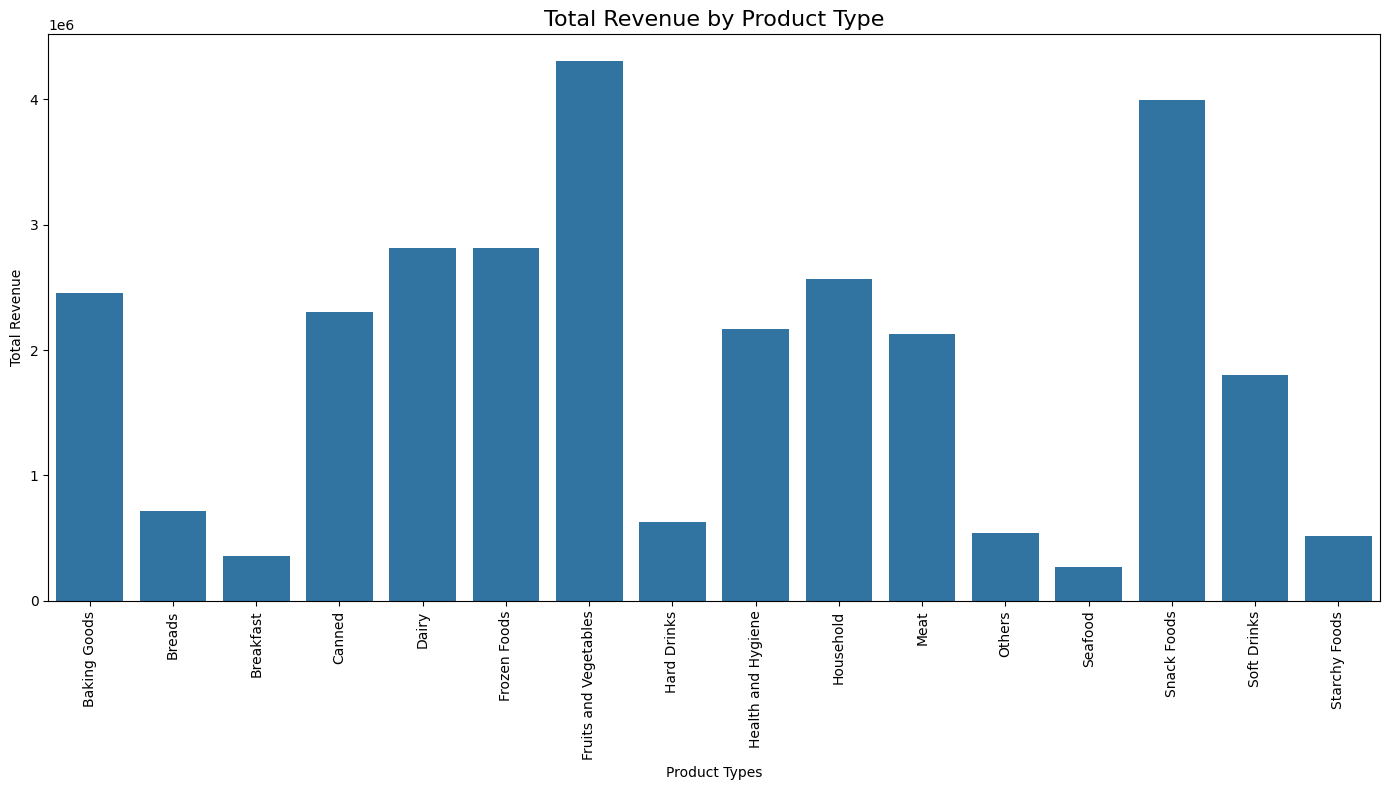

In [36]:


df_revenue1 = data.groupby(
    ["Product_Type"], as_index=False
)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=[14, 8])

a = sns.barplot(
    x=df_revenue1.Product_Type,
    y=df_revenue1.Product_Store_Sales_Total
)

a.set_xlabel("Product Types")
a.set_ylabel("Total Revenue")
a.set_title("Total Revenue by Product Type", fontsize=16)



plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

We see that the most revenue is being made by Snack Foods and Fruits and Vegetables.

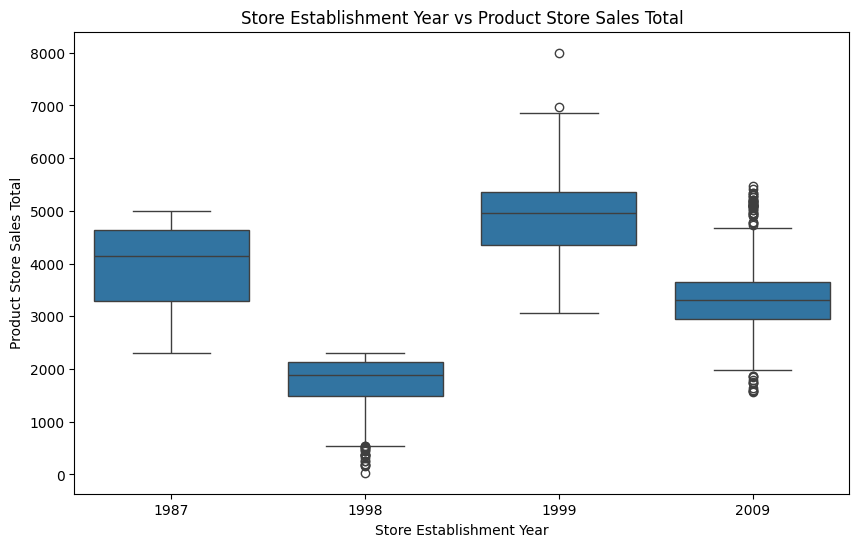

Store_Establishment_Year
1987    3923.778802
1998    1762.942465
1999    4946.966323
2009    3299.312111
Name: Product_Store_Sales_Total, dtype: float64

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x='Store_Establishment_Year',
    y='Product_Store_Sales_Total'
)

plt.title('Store Establishment Year vs Product Store Sales Total')
plt.xlabel('Store Establishment Year')
plt.ylabel('Product Store Sales Total')
plt.show()

data.groupby('Store_Establishment_Year')['Product_Store_Sales_Total'].mean().sort_index()

Looking at the 4 stores, we see that the store from 1999 has the highest average total sales per product, and the store from 1998 by far has the least.

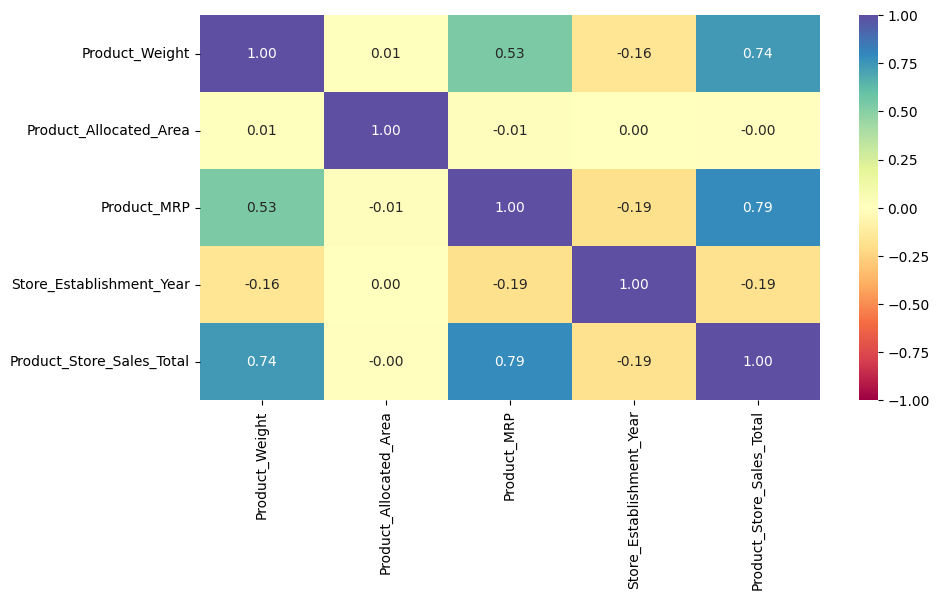

In [33]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

#Correlation Matrix to see which factors are correlated together 

We see that in regards to sales, product MRP and weight are most allocated

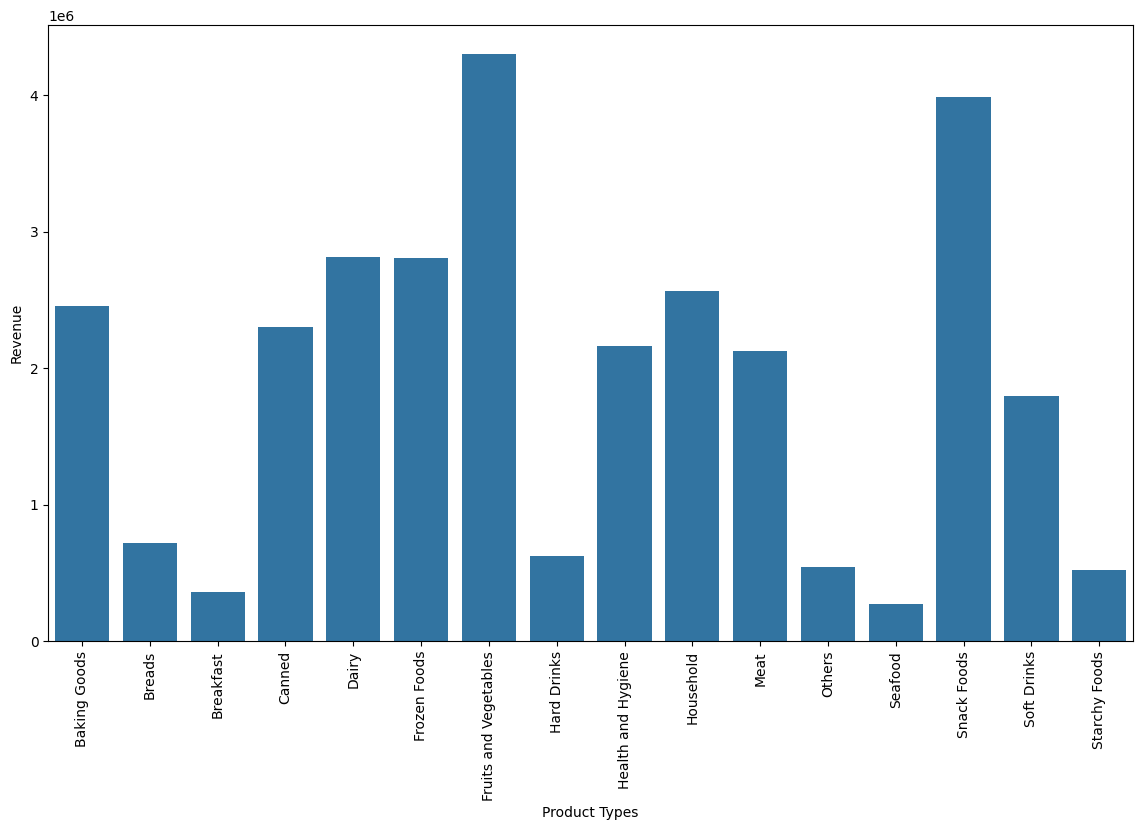

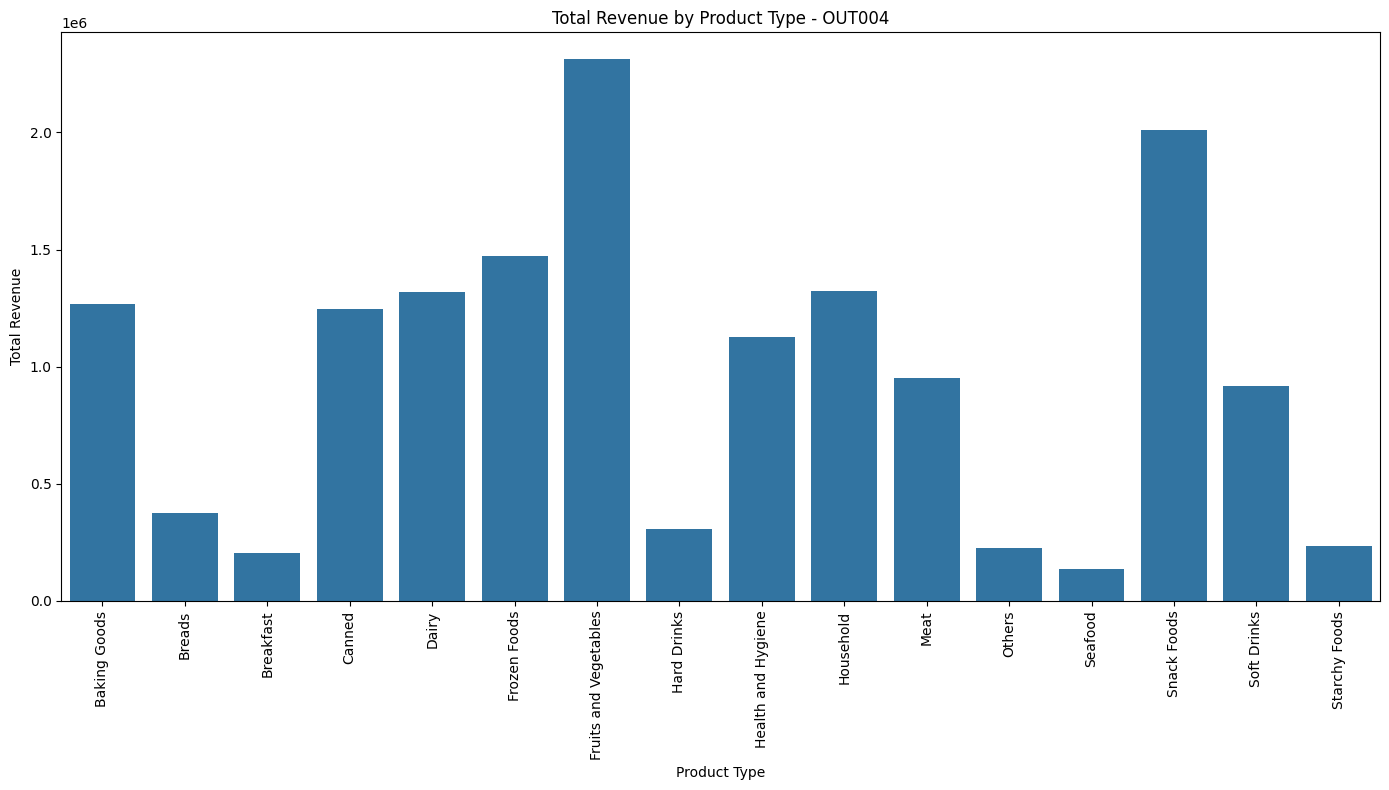

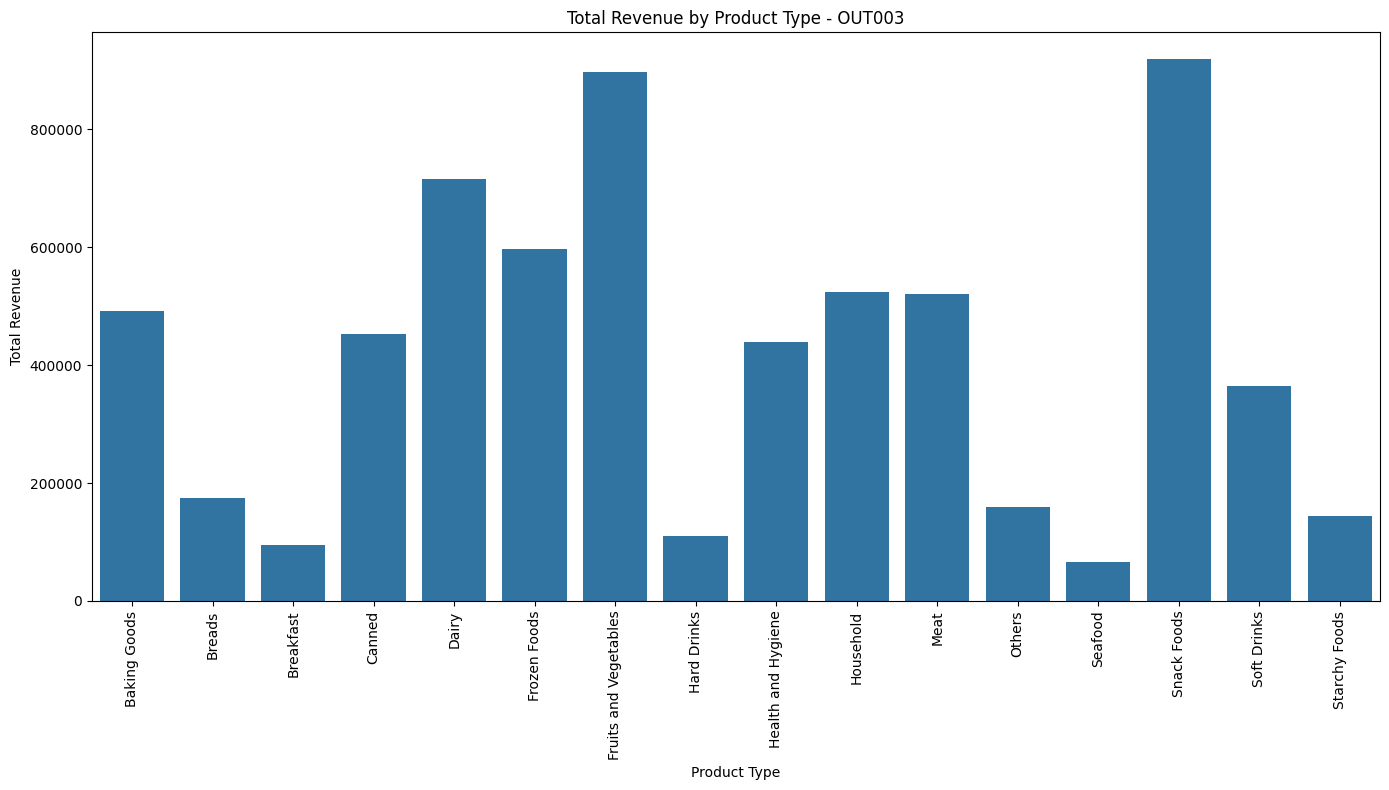

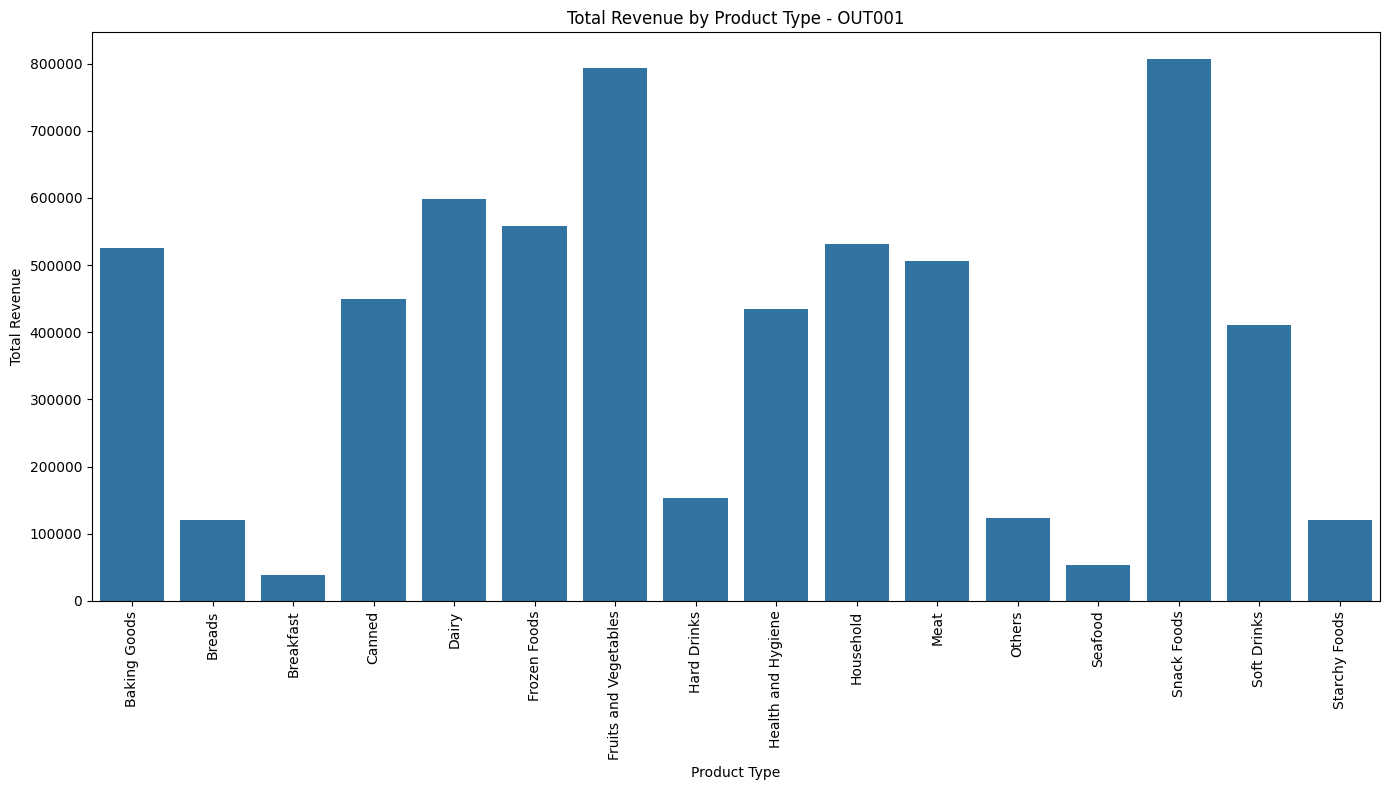

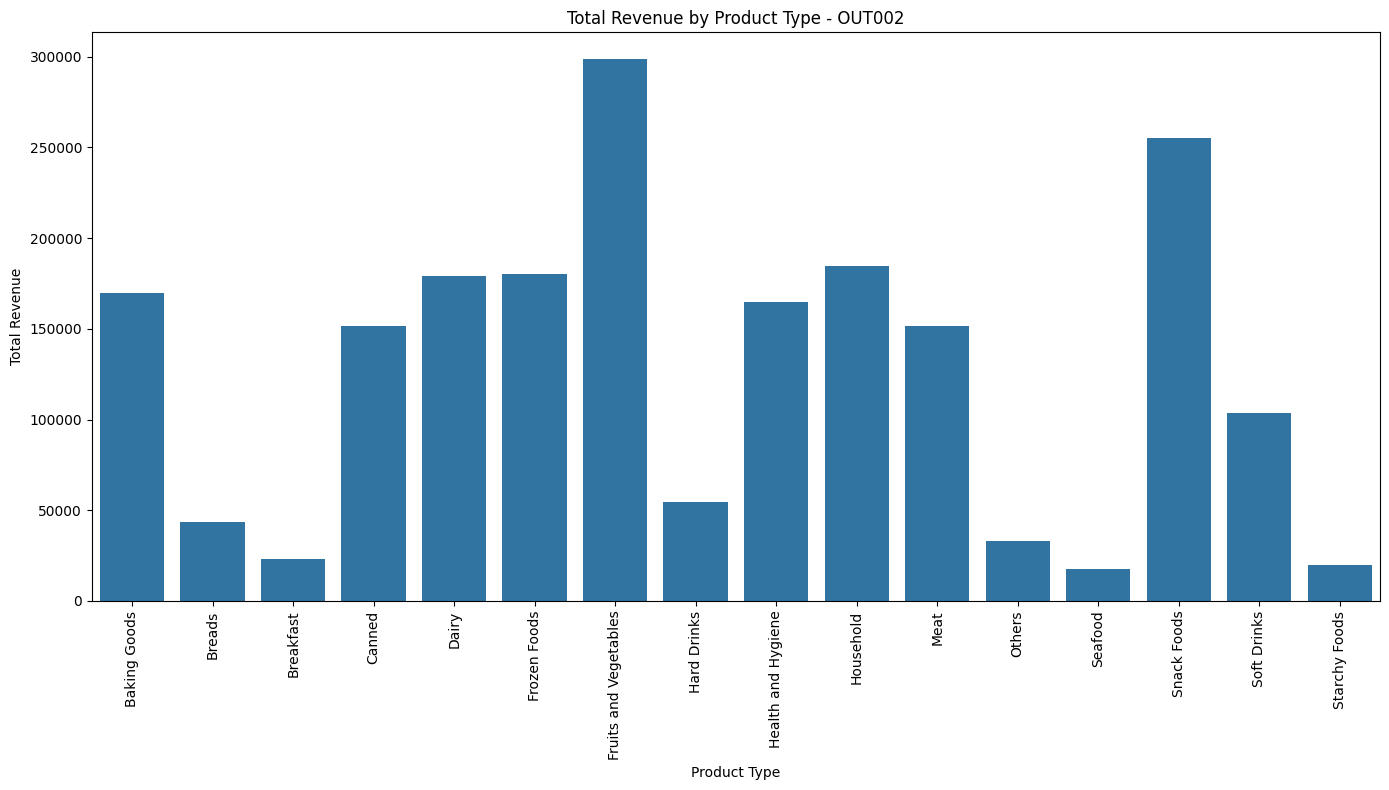

In [42]:
#I also want to understand the relationships between the stores and all the descriptive columns for stores. 
#looping through all of the stores



# Loop through each unique Store_Id
for store_id in data["Store_Id"].unique():

    # Filter data for the current store and group by Product Type
    df_store = (
        data.loc[data["Store_Id"] == store_id]
        .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
        .sum()
    )

    # Create plot
    plt.figure(figsize=[14, 8])

    sns.barplot(
        x=df_store["Product_Type"],
        y=df_store["Product_Store_Sales_Total"]
    )

    # Labels and title
    plt.xlabel("Product Type")
    plt.ylabel("Total Revenue")
    plt.title(f"Total Revenue by Product Type - {store_id}")
  

    # Rotate product type labels
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

In [47]:
store_product_revenue = (
    data.groupby(["Store_Id", "Product_Type"])["Product_Store_Sales_Total"]
    .sum()
    .unstack(fill_value=0)
)

store_product_revenue

Product_Type,Baking Goods,Breads,Breakfast,Canned,Dairy,Frozen Foods,Fruits and Vegetables,Hard Drinks,Health and Hygiene,Household,Meat,Others,Seafood,Snack Foods,Soft Drinks,Starchy Foods
Store_Id,,,,,,,,,,,,,,,,
OUT001,525131.04,121274.09,38161.10,449016.38,598767.62,558556.81,792992.59,152920.74,435005.31,531371.38,505867.28,123977.09,52936.84,806142.24,410548.69,120443.98
OUT002,169860.50,43419.47,23396.10,151467.66,178888.18,180295.95,298503.56,54281.85,164660.81,184665.65,151800.01,32835.73,17663.35,255317.57,103808.35,20044.98
OUT003,491908.20,175391.93,95634.08,452445.17,715814.94,597608.42,897437.46,110760.30,439139.18,523981.64,520939.68,159963.75,65337.48,918510.44,365046.30,143538.60
OUT004,1266086.26,374856.75,204939.13,1247153.50,1318447.30,1473519.65,2311899.66,307851.73,1124901.91,1324721.50,950604.97,224719.73,136466.37,2009026.70,917641.38,234746.89


In [48]:
store_comparison = pd.DataFrame({
    "Highest_Revenue_Store": store_product_revenue.idxmax(),
    "Highest_Revenue": store_product_revenue.max(),
    "Lowest_Revenue_Store": store_product_revenue.idxmin(),
    "Lowest_Revenue": store_product_revenue.min(),
    "Difference": (
        store_product_revenue.max() - store_product_revenue.min()
    )
}).sort_values("Difference", ascending=False)

store_comparison

,Highest_Revenue_Store,Highest_Revenue,Lowest_Revenue_Store,Lowest_Revenue,Difference
Product_Type,,,,,
Fruits and Vegetables,OUT004,2311899.66,OUT002,298503.56,2013396.10
Snack Foods,OUT004,2009026.70,OUT002,255317.57,1753709.13
Frozen Foods,OUT004,1473519.65,OUT002,180295.95,1293223.70
Household,OUT004,1324721.50,OUT002,184665.65,1140055.85
Dairy,OUT004,1318447.30,OUT002,178888.18,1139559.12
Baking Goods,OUT004,1266086.26,OUT002,169860.50,1096225.76
Canned,OUT004,1247153.50,OUT002,151467.66,1095685.84
Health and Hygiene,OUT004,1124901.91,OUT002,164660.81,960241.10
Soft Drinks,OUT004,917641.38,OUT002,103808.35,813833.03


I produced a couple of tables to see which stores are the highest and lowest revenue store per category of product. We see a clear trend of store OUT004 being the most revenue and OUT002 being the least.

# **Data Preprocessing**

In [49]:
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [50]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

It seems like products are split by ID in 3 different prefixes, so i will add a new feature splitting products by these 3 categories

In [53]:
data["product_id_type"] = data["Product_Id_char"]
data["product_id_type"].unique()

data = data.drop(columns=["Product_Id_char"])

In [ ]:
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year #Engineering a better numerical indicator for store age years

In [ ]:
#Grouping Products by Perishable vs Non Perishable

perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"
    
    
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [56]:
#Outlier Check


numeric_cols = data.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower_bound) | (data[col] > upper_bound)
    ]

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": (len(outliers) / len(data)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Product_Weight,6.6050,18.7250,54,0.616227
1,Product_Allocated_Area,-0.0665,0.1935,104,1.186808
2,Product_MRP,64.0225,229.7225,57,0.650462
3,Store_Establishment_Year,1981.5000,2025.5000,0,0.000000
4,Product_Store_Sales_Total,686.5400,6220.3400,119,1.357982
5,Store_Age_Years,-0.5000,43.5000,0,0.000000


In [58]:
data[data['Product_Allocated_Area'] < 0]


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,product_id_type,Store_Age_Years


In [59]:
data[data['Store_Age_Years'] < 0]

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,product_id_type,Store_Age_Years


Looking at the outlier summary, I don't see any abnormal upper or lower bounds. I confirmed that there are no allocated areas or store age years that are actually negative

# **Model Building**

## Define functions for Model Evaluation

In [60]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

I am going to attempt a decision tree and a random forest models

Decision Tree

In [80]:
X = data.drop(columns=["Product_Store_Sales_Total"])
y = data["Product_Store_Sales_Total"]

#Defining X and Y

In [81]:
#Removing uneccessary collumns
X = X.drop(columns=["Product_Id", "Store_Id"])

In [82]:
#Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1
)

In [83]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Store_Age_Years']
Categorical: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'product_id_type']


We need to create a preproccessor so that we can handle categorical variables. 

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [85]:
dtree = DecisionTreeRegressor(random_state=1)
dtree = make_pipeline(preprocessor,dtree)
dtree.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year',
                                                   'Store_Age_Years']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'product_id_type'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=1))])

In [86]:
y_pred = dtree.predict(X_test)
#Make Predictions

In [87]:
dtree_train_perf = model_performance_regression(
    dtree,
    X_train,
    y_train
)

dtree_test_perf = model_performance_regression(
    dtree,
    X_test,
    y_test
)

print("Training Performance")
display(dtree_train_perf)

print("Test Performance")
display(dtree_test_perf)

#Using the provided evaluation function

Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.0,0.0,1.0,1.0,0.0


Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,373.539362,127.308969,0.878069,0.877557,0.054884


Based on these initial results, we can see that the decision tree is overfitting the data, but still performing well on the unseen data, with a R2 of .87. The model currently explains approximately 87.8% of the variation in Product_Store_Sales_Total.

Random Forest: choosing to build random forest next makes sense as my target is continuous, and a decision tree already performed well with numerical and categorical variables.

In [88]:
#Using the same x train and test set, as well as preprocessor
rf_estimator = RandomForestRegressor(random_state=1)

rf_estimator = make_pipeline(
    preprocessor,
    rf_estimator
)

rf_estimator.fit(X_train, y_train)



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year',
                                                   'Store_Age_Years']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'product_id_type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

In [89]:
rf_train_perf = model_performance_regression(
    rf_estimator,
    X_train,
    y_train
)

rf_test_perf = model_performance_regression(
    rf_estimator,
    X_test,
    y_test
)

print("Training Performance")
display(rf_train_perf)

print("Test Performance")
display(rf_test_perf)

Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,103.669336,39.827905,0.990502,0.990485,0.014077


Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,294.012523,111.37734,0.924461,0.924143,0.050377


The Random Forest  outperforms the Decision Tree on the test set, with a lower RMSE and MAE, and a higher R² (0.9245), indicating better predictive accuracy. The small gap between training R² (0.9905) and test R² (0.9245) suggests some overfitting, but not as major as the initial decision tree

# **Model Performance Improvement - Hyperparameter Tuning**

Decision Tree Tuning: I want to try to work against over-fitting. We need to add some restrictions to the tree

In [95]:
dtree_tuned = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=1
)
dtree_tuned = make_pipeline(preprocessor,dtree_tuned)
dtree_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year',
                                                   'Store_Age_Years']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'product_id_type'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=5,
                                       min_samples_split=10, random_state=1))])

In [ ]:
y_pred = dtree_tuned.predict(X_test)

In [97]:
dtree_tuned_train_perf = model_performance_regression(
    dtree_tuned,
    X_train,
    y_train
)

dtree_tuned_test_perf = model_performance_regression(
    dtree_tuned,
    X_test,
    y_test
)

print("Training Performance")
display(dtree_tuned_train_perf)

print("Test Performance")
display(dtree_tuned_test_perf)

Training Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,251.605339,116.669201,0.944052,0.943951,0.03959


Test Performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,315.034521,146.060315,0.913273,0.912908,0.062769


After tuning the max depth,  min_samples_split, min_samples_leaf, and random_state, we were able to increase the r squared of the test performance evaluation. we did this by making adjustments in tuning to simplify the tree in some regards, and not allow it to overfit against the training data. Larger Groups and smoother predicitons lead to better test performance. 


Hyper Tuning the Random Forest Model

In [ ]:
param_grid = {
    "randomforestregressor__n_estimators": [100, 200, 300, 500],
    "randomforestregressor__max_depth": [None, 10, 15, 20, 25, 30],
    "randomforestregressor__min_samples_split": [2, 5, 10],
    "randomforestregressor__min_samples_leaf": [1, 2, 4],
    "randomforestregressor__max_features": [0.5, 0.75, 1.0]
}

#We are going to start by defining the most important paramaters to the model 

In [92]:
from sklearn.model_selection import RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf_estimator,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=1,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
#I am now going to iterate with RamdomSearchCV to get the best paramaters

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['Product_Weight',
                                                                                'Product_Allocated_Area',
                                                                                'Product_MRP',
                                                                                'Store_Establishment_Year',
                                                                                'Store_Age_Years']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Product_Sugar_Content',
                                                                                'Product_Type',
                                                                                'Store_Size',
                                                                                'Store_Location_City_Ty...
                   n_iter=30, n_jobs=-1,
                   param_distributions={'randomforestregressor__max_depth': [None,
                                                                             10,
                                                                             15,
                                                                             20,
                                                                             25,
                                                                             30],
                                        'randomforestregressor__max_features': [0.5,
                                                                                0.75,
                                                                                1.0],
                                        'randomforestregressor__min_samples_leaf': [1,
                                                                                    2,
                                                                                    4],
                                        'randomforestregressor__min_samples_split': [2,
                                                                                     5,
                                                                                     10],
                                        'randomforestregressor__n_estimators': [100,
                                                                                200,
                                                                                300,
                                                                                500]},
                   random_state=1, scoring='neg_root_mean_squared_error')

In [93]:
print(rf_random.best_params_)

{'randomforestregressor__n_estimators': 500, 'randomforestregressor__min_samples_split': 5, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__max_features': 0.75, 'randomforestregressor__max_depth': 25}


In [94]:
#Now we re-compute the model with the best paramaters
best_rf = rf_random.best_estimator_
rf_tuned_train = model_performance_regression(
    best_rf,
    X_train,
    y_train
)

rf_tuned_test = model_performance_regression(
    best_rf,
    X_test,
    y_test
)

print("Tuned Random Forest - Training")
display(rf_tuned_train)

print("Tuned Random Forest - Test")
display(rf_tuned_test)

Tuned Random Forest - Training


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,176.403069,63.799767,0.972498,0.972449,0.022595


Tuned Random Forest - Test


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.21902,108.360216,0.927409,0.927103,0.049308


The tuned Random Forest slightly improves upon the original Random Forest, reducing test RMSE from 294.01 to 288.22, MAE from 111.38 to 108.36, and MAPE from 5.04% to 4.93%, while increasing R2 from 0.9245 to 0.9274. The training-to-test gap indicates some overfitting, but the model still generalizes well and explains approximately 92.7% of the variation in sales.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
models_train_comp_df = pd.concat(
    [
        dtree_train_perf.T,
        dtree_tuned_train_perf.T,
        rf_train_perf.T,
        rf_tuned_train.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest"
]

print("Training performance comparison:")
models_train_comp_df

#Using the provided function to compare models

Training performance comparison:


,Decision Tree,Tuned Decision Tree,Random Forest,Tuned Random Forest
RMSE,0.0,251.605339,103.669336,176.403069
MAE,0.0,116.669201,39.827905,63.799767
R-squared,1.0,0.944052,0.990502,0.972498
Adj. R-squared,1.0,0.943951,0.990485,0.972449
MAPE,0.0,0.039590,0.014077,0.022595


In [106]:
models_test_comp_df = pd.concat(
    [
        dtree_test_perf.T,
        dtree_tuned_test_perf.T,
        rf_test_perf.T,
        rf_tuned_test.T,
    ],
    axis=1,
)


models_test_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Tuned Decision Tree,Random Forest,Tuned Random Forest
RMSE,373.539362,315.034521,294.012523,288.219020
MAE,127.308969,146.060315,111.377340,108.360216
R-squared,0.878069,0.913273,0.924461,0.927409
Adj. R-squared,0.877557,0.912908,0.924143,0.927103
MAPE,0.054884,0.062769,0.050377,0.049308


In [ ]:
#Model Serialization

os.makedirs("backend_files", exist_ok=True)
saved_model_path = "backend_files/tuned_random_forest.joblib" 
joblib.dump(best_rf, saved_model_path) 

print(f"Model saved successfully at {saved_model_path}")


Model saved successfully at backend_files/tuned_random_forest.joblib


In [109]:
saved_model = joblib.load("backend_files/tuned_random_forest.joblib") #Complete the code to define the name of the saved model

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [110]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year',
                                                   'Store_Age_Years']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'product_id_type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=25, max_features=0.75,
                                       min_samples_leaf=2, min_samples_split=5,
                                       n_estimators=500, random_state=1))])

We confirm here that model is saved and loaded correctly

After looking through results, we will choose the Tuned Random Forest, as it wins on every evaluation metric. 

# **Deployment - Backend**

## Flask Web Framework


In [111]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize Flask app with a name
superkart_api = Flask("superkart_api")

# Load the trained sales prediction model
model = joblib.load("backend_files/rf_tuned_model.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart Sales Prediction API!"

# Define an endpoint to predict sales for a single product/store
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant features from the input data
    sample = {
        'Product_Weight': data['Product_Weight'],
        'Product_Sugar_Content': data['Product_Sugar_Content'],
        'Product_Allocated_Area': data['Product_Allocated_Area'],
        'Product_MRP': data['Product_MRP'],
        'Store_Size': data['Store_Size'],
        'Store_Location_City_Type': data['Store_Location_City_Type'],
        'Store_Type': data['Store_Type'],
        'Product_Id_char': data['Product_Id_char'],
        'Store_Age_Years': data['Store_Age_Years'],
        'Product_Type_Category': data['Product_Type_Category']
    }

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a sales prediction
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

Writing backend_files/app.py


## Dependencies File

In [112]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
joblib==1.4.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3
uvicorn[standard]
streamlit==1.43.2

Writing backend_files/requirements.txt


## Dockerfile

In [114]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app from app.py using the Flask instance named superkart_api
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

## Dependencies File

## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

## Uploading Files to Hugging Face Space (Streamlit Space)

# **Actionable Insights and Business Recommendations**

-

-